In [1]:
import numpy as np
from utils.load_preprocess import load_preprocess
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

# Initialize rng
rng = np.random.default_rng(2022)

# # Genes
# selecting top 100 genes gives 81 from feature selection using stability
# selecting top 500 genes gives 4111 from feature selection using stability
n_genes = 100

In [2]:
X = load_preprocess(n_genes, as_df=True)
y = X['class'].to_numpy()
X.drop('class', 1, inplace=True)

i =  0
j =  0
j =  20
j =  40
j =  60
j =  80
j =  100
j =  120
j =  140
j =  160
j =  180
j =  200
j =  220
j =  240
j =  260
j =  280
j =  300
j =  320
j =  340
j =  360
j =  380
j =  400
j =  420
j =  440
j =  460
j =  480
j =  500
j =  520
j =  540
j =  560
j =  580
j =  600
j =  620
j =  640
j =  660
j =  680
j =  700
j =  720
j =  740
j =  760
j =  780
j =  800
j =  820
j =  840
j =  860
j =  880
j =  900
j =  920
j =  940
j =  960
j =  980
i =  1
j =  0
j =  20
j =  40
j =  60
j =  80
j =  100
j =  120
j =  140
j =  160
j =  180
j =  200
j =  220
j =  240
j =  260
j =  280
j =  300
j =  320
j =  340
j =  360
j =  380
j =  400
j =  420
j =  440
j =  460
j =  480
j =  500
j =  520
j =  540
j =  560
j =  580
j =  600
j =  620
j =  640
j =  660
j =  680
j =  700
j =  720
j =  740
j =  760
j =  780
j =  800
j =  820
j =  840
j =  860
j =  880
j =  900
j =  920
j =  940
j =  960
j =  980
i =  2
j =  0
j =  20
j =  40
j =  60
j =  80
j =  100
j =  120
j =  140
j =  160
j =  180
j =  20

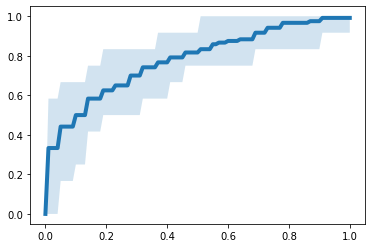

In [6]:
# # times to run bootstrap
n_bootstrap = 10

# # of hyperparameter combinations to try in random search
n_combinations = 1000

# Build an FPR grid to generate TPR on a grid
fpr_grid_vec = np.linspace(0, 1, 101, endpoint=True)
tpr_grid_mat = np.zeros((len(fpr_grid_vec), n_bootstrap))

# Maintain a list of AUROC scores
auroc_list = []
best_auroc_yet = 0.0
best_model_yet = None


for i in range(n_bootstrap):
    print('i =', i)
    # Split into train, validation, and test
    X_train_val, X_test, y_train_val, y_test = train_test_split(X,
                                                            y,
                                                            stratify=y,
                                                            test_size=0.2,
                                                            random_state=rng.integers(500000))
    X_train, X_val, y_train, y_val = train_test_split(X_train_val,
                                                    y_train_val,
                                                    stratify=y_train_val,
                                                    test_size=0.2,
                                                    random_state=rng.integers(500000))
    
    # Hyperparameter tuning
    prev_best_auroc = 0.0
    prev_best_test_pred = None
    prev_best_model = None
    for j in range(n_combinations):
        if j%20 == 0:
            print('j =', j)
        
        # Generate random values for hyperparameters
        # Generate number of trees between 10-1000
        n_estimators = rng.integers(low=10, high=1001)
        # Generate max_depth between 5-100
        max_depth = rng.integers(low=5, high=101)
        # Generate min_samples_split between 2-10
        min_samples_split = rng.integers(low=2, high=11)
        # Generate min_samples_leaf between 1-5
        min_samples_leaf = rng.integers(low=1, high=6)
        # Generate max_features as 'sqrt' or 'log2'
        max_features_list = ['sqrt', 'log2']
        max_features = max_features_list[rng.integers(low=0, high=2)]
        
    
        model = RandomForestClassifier(n_estimators=n_estimators,
                                       max_depth=max_depth,
                                       min_samples_split=min_samples_split,
                                       min_samples_leaf=min_samples_leaf,
                                       max_features=max_features,
                                       n_jobs=1000,
                                       random_state=rng.integers(500000))
        # Fit on training data
        model.fit(X_train, y_train)

        # Get predictions on validation set
        y_pred = model.predict_proba(X_val)

        # Calculate AUROC
        auroc = roc_auc_score(y_val, y_pred[:,1])

        # Save if this is the best model
        if auroc > prev_best_auroc:
            # Save the latest best AUROC
            prev_best_auroc = auroc
            # Save the predictions of this model for the test set
            prev_best_test_pred = model.predict_proba(X_test)
            prev_best_model = model
                            
    if prev_best_auroc > best_auroc_yet:
        best_auroc_yet = prev_best_auroc
        best_model_yet = prev_best_model
        
    fpr, tpr, _ = roc_curve(y_true=y_test, y_score=prev_best_test_pred[:,1])
    fpr = np.concatenate(([0], fpr, [1]))
    tpr = np.concatenate(([0], tpr, [1]))

    interpolator = interp1d(fpr, tpr, kind='nearest')

    tpr_grid_mat[:, i] = interpolator(fpr_grid_vec)

    auroc_list.append(roc_auc_score(y_test, prev_best_test_pred[:,1]))
    
# confidence interval for AUCs
sorted_scores = np.array(auroc_list)
sorted_scores.sort()
auroc_mean = np.mean(sorted_scores)
confidence_lower = sorted_scores[int(0.05 * len(sorted_scores))]
confidence_upper = sorted_scores[int(0.95 * len(sorted_scores))]
print('AUROC: {} [CI {} - {}]'.format(auroc_mean, confidence_lower, confidence_upper))

# Plot
# confidence interval for ROC
tpr_grid_mats = np.sort(tpr_grid_mat, axis=1)
tpr_low_05 = tpr_grid_mats[:, int(0.05 * n_bootstrap)]
tpr_top_95 = tpr_grid_mats[:, int(0.95 * n_bootstrap)]
tpr_mean = np.mean(tpr_grid_mat, axis=1)

# plt.hold(True)
ax = plt.gca()  # kwargs.pop('ax', plt.gca())
base_line, = ax.plot(fpr_grid_vec, tpr_mean, '-', linewidth=4)
ax.fill_between(fpr_grid_vec, tpr_low_05, tpr_top_95, facecolor=base_line.get_color(), alpha=0.2);

In [19]:
best_model_yet

RandomForestClassifier(max_depth=93, max_features='log2', min_samples_split=8,
                       n_estimators=24, n_jobs=1000, random_state=454915)

# Interpretation

In [38]:
import shap
explainer = shap.TreeExplainer(best_model_yet)
shap_values = explainer.shap_values(X)[1]

In [42]:
shap.initjs() 
shap.force_plot(explainer.expected_value[0], shap_values[0], X.iloc[0])

In [46]:
explainer.expected_value[1]

0.37499999999999994

In [47]:
shap.force_plot(explainer.expected_value[1], shap_values, X)

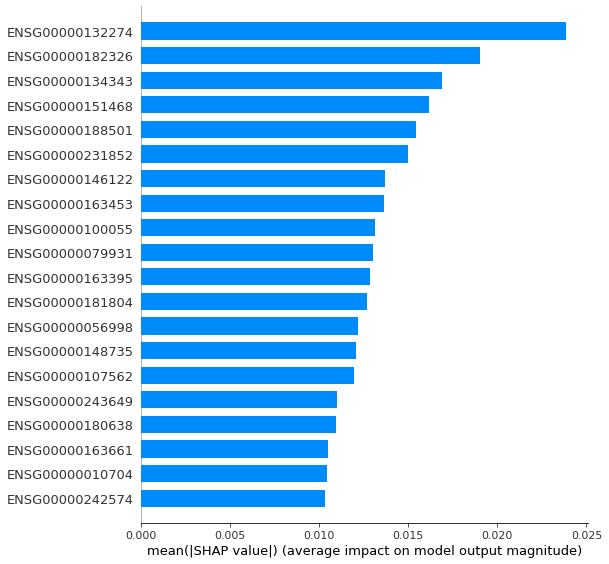

In [48]:
# Bar chart of mean importance
shap.summary_plot(shap_values, X, plot_type="bar")

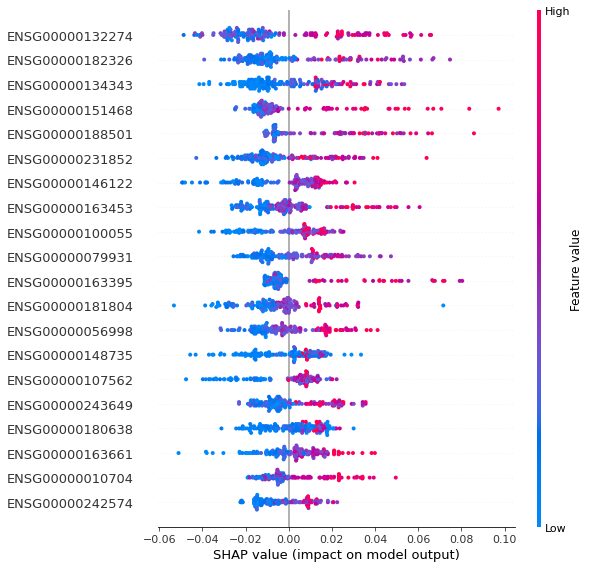

In [49]:
# Summary plot
shap.summary_plot(shap_values, X)